In [586]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pyexpat import features
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve

In [587]:


cols = ["age","sex","cp","trestbps","chol","fbs","restecg",
        "thalach","exang","oldpeak","slope","ca","thal","target"]

df = pd.read_csv("processed.cleveland.data", names=cols, na_values="?")

# reemplazar missing values
df = df.replace("?", pd.NA)
df["target"] = df["target"].apply(lambda x: 1 if int(x) > 0 else 0)
print(f"descripción de variables:  {df.shape}")
df.head()


descripción de variables:  (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Balance de clases 

In [588]:

# INSPECCIÓN GENERAL
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [589]:

# VALORES NULOS
print("Valores nulos por columna = ")
print(df.isnull().sum())

Valores nulos por columna = 
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


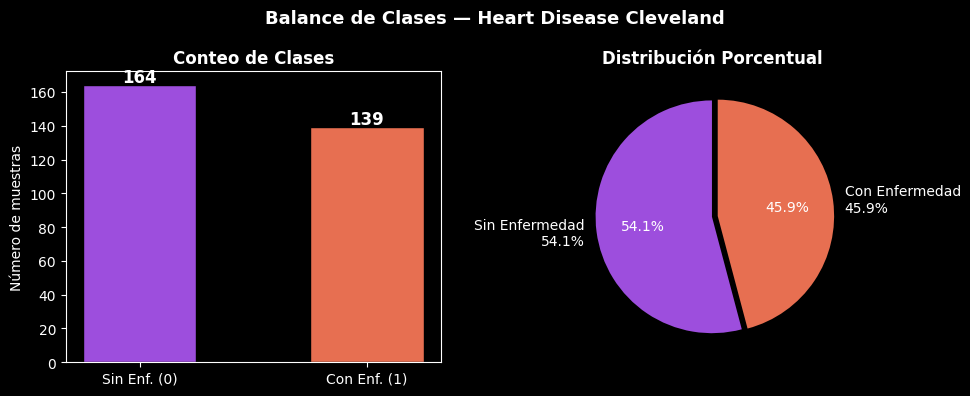

In [590]:
# Gráficas de balanceo 

conteo  = df['target'].value_counts()
balance = df['target'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colores = ["#9D4EDD", "#e76f51"]  

axes[0].bar(['Sin Enf. (0)', 'Con Enf. (1)'], conteo.values, color=colores, edgecolor='black', width=0.5)
axes[0].set_title('Conteo de Clases', fontweight='bold')
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(conteo.values,
            labels=[f'Sin Enfermedad\n{balance[0]:.1f}%', f'Con Enfermedad\n{balance[1]:.1f}%'],
            colors=colores, autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Distribución Porcentual', fontweight='bold')

plt.suptitle('Balance de Clases — Heart Disease Cleveland', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [591]:
print('                 Balance de Clases \n')

# Conteo y porcentajes
conteo = df['target'].value_counts()
porcentaje = df['target'].value_counts(normalize=True) * 100

# Mostrar distribución
print(f'  Clase 0 (Sin enfermedad): {conteo[0]} muestras ({porcentaje[0]:.1f}%)')
print(f'  Clase 1 (Con enfermedad): {conteo[1]} muestras ({porcentaje[1]:.1f}%)')

# Ratio estándar (recomendado)
ratio = conteo.max() / conteo.min()

print(f'\n  Ratio de desbalance (mayoritaria/minoritaria): {ratio:.2f}:1')

# Interpretación automática
if ratio < 1.5:
    print("\n  Conclusión: Dataset balanceado")
elif ratio < 3:
    print("\n  Conclusión: Dataset levemente desbalanceado")
else:
    print("\n  Conclusión: Dataset desbalanceado")    

                 Balance de Clases 

  Clase 0 (Sin enfermedad): 164 muestras (54.1%)
  Clase 1 (Con enfermedad): 139 muestras (45.9%)

  Ratio de desbalance (mayoritaria/minoritaria): 1.18:1

  Conclusión: Dataset balanceado


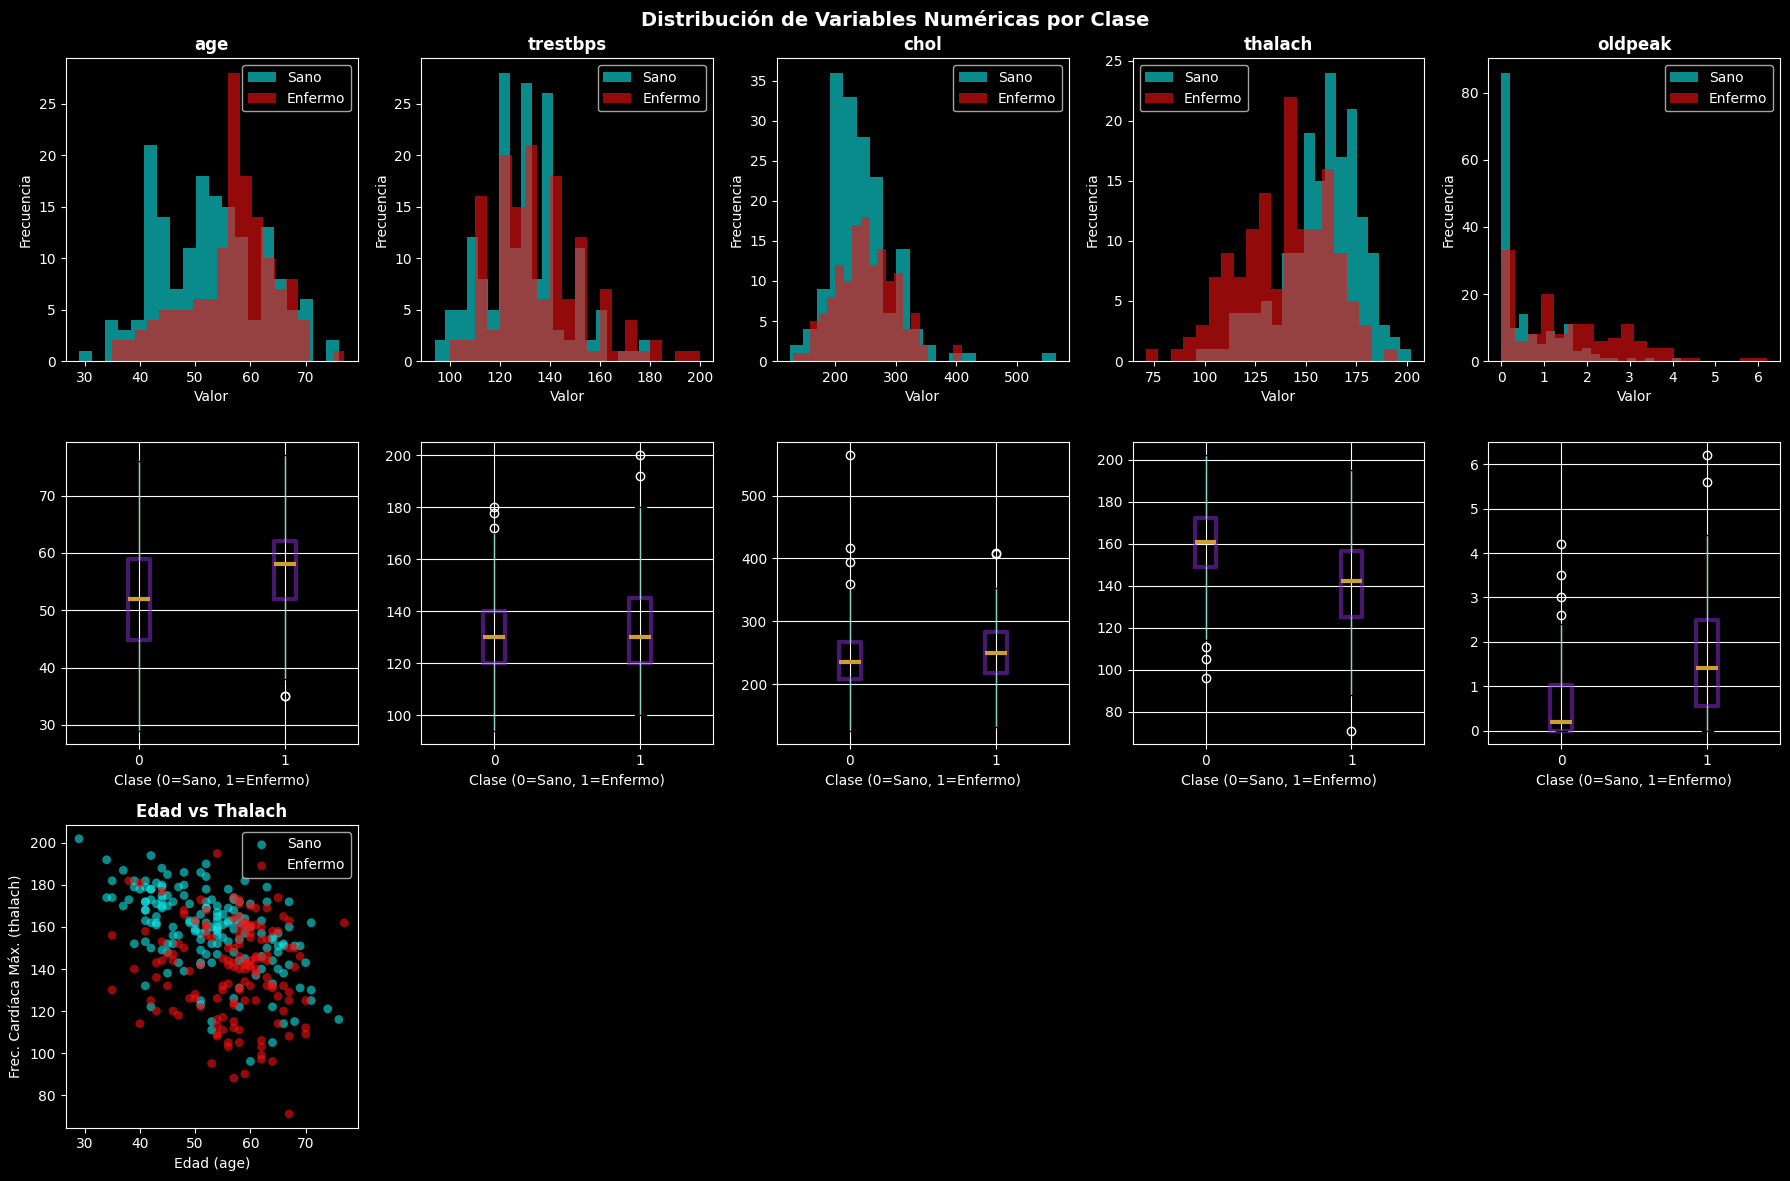

In [592]:
numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(3, len(numericas), figsize=(18, 12))

for i, col in enumerate(numericas):

    #Histograma por clase

    for clase, color, label in [(0, "#12e9e9", 'Sano'), (1, "#f51111", 'Enfermo')]:
        axes[0, i].hist(df[df['target'] == clase][col].dropna(),
                        bins=20, alpha=0.6, color=color, label=label)
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].legend()
    axes[0, i].set_xlabel('Valor')
    axes[0, i].set_ylabel('Frecuencia')

    #Boxplot por clase

    df.boxplot(column=col, by='target', ax=axes[1, i],
               boxprops=dict(color="#832cc98e", linewidth=3),
               medianprops=dict(color="#cd9f32", linewidth=3))
    axes[1, i].set_title('')
    axes[1, i].set_xlabel('Clase (0=Sano, 1=Enfermo)')

# Fila 2: Scatter age vs thalach (solo en las dos primeras columnas, el resto se oculta)

for clase, color, label in [(0, "#12e9e9", 'Sano'), (1, "#f51111", 'Enfermo')]:
    axes[2, 0].scatter(
        df[df['target'] == clase]['age'],
        df[df['target'] == clase]['thalach'],
        alpha=0.6, color=color, label=label, s=40, edgecolors='none'
    )

axes[2, 0].set_xlabel('Edad (age)')
axes[2, 0].set_ylabel('Frec. Cardíaca Máx. (thalach)')
axes[2, 0].set_title('Edad vs Thalach', fontweight='bold')
axes[2, 0].legend()

# Ocultar los subplots vacíos de la fila 2

for j in range(1, len(numericas)):
    axes[2, j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



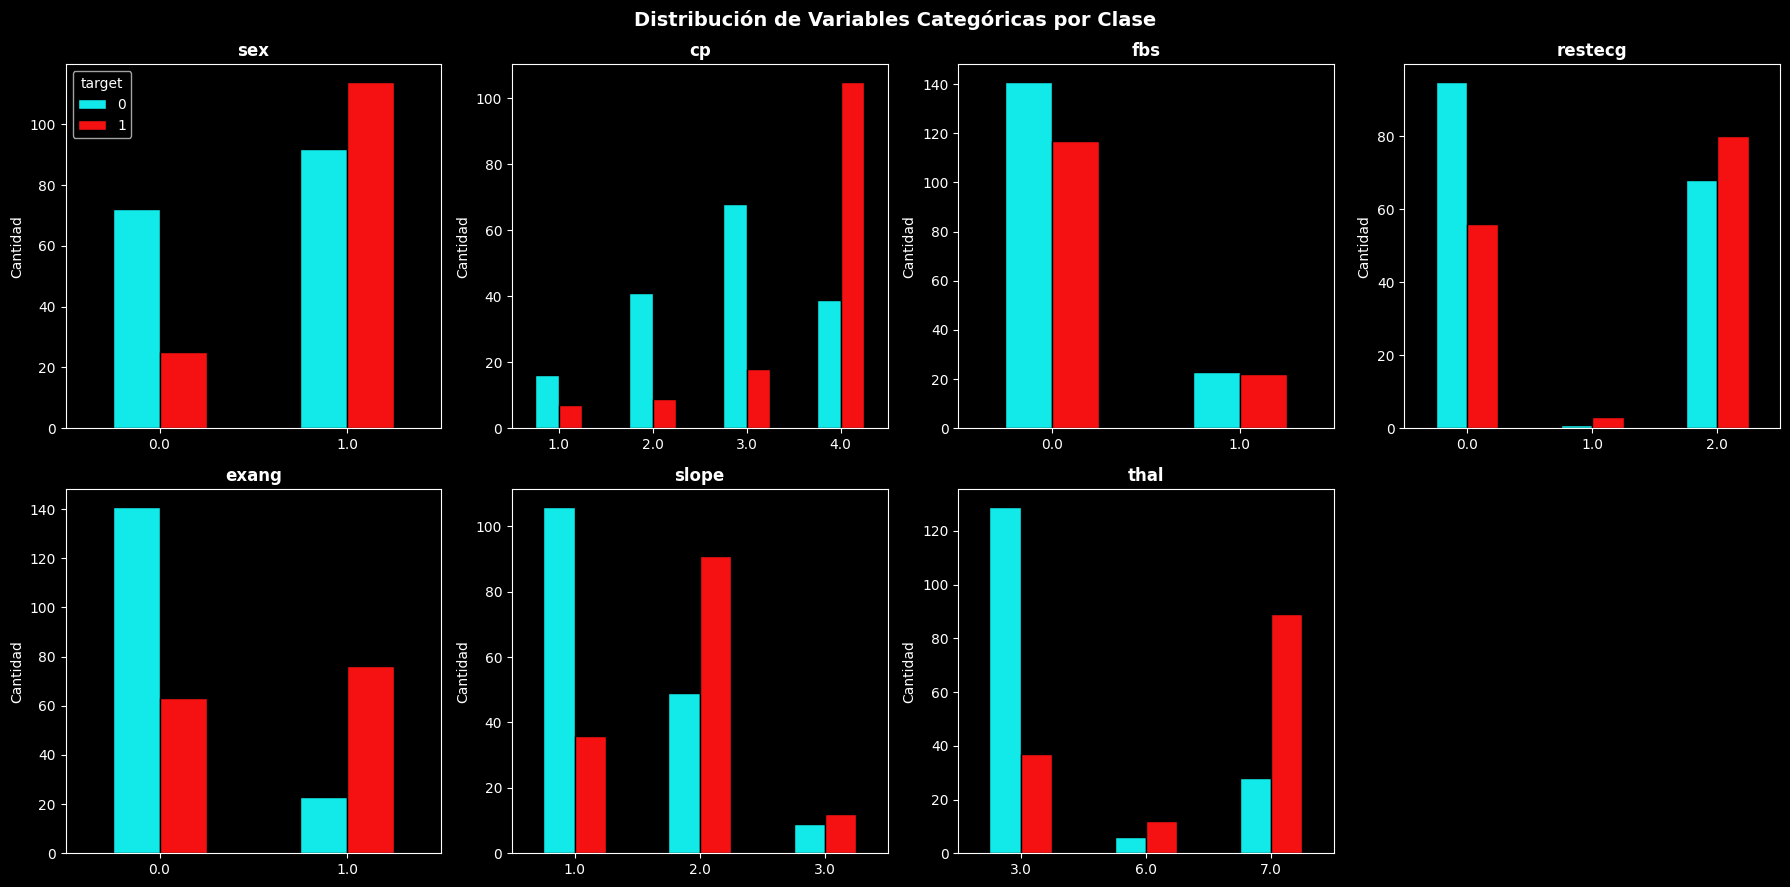

In [593]:
categoricas = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten() 

for i, col in enumerate(categoricas):
    tabla = df.groupby([col, 'target']).size().unstack(fill_value=0) 
    tabla.plot(kind='bar', ax=axes[i], color=['#12e9e9', '#f51111'],
               edgecolor='black', legend=(i == 0))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=0)

# Quitar el subplot sobrante
axes[-1].set_visible(False)

plt.suptitle('Distribución de Variables Categóricas por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

******Esto quiere decir******

- **age**: Edad del paciente (años)
- **sex**: Sexo (1 = masculino, 0 = femenino)
- **cp**: Tipo de dolor en el pecho (1=angina típica, 2=angina atípica, 3=no anginal, 4=asintomático)
- **trestbps**: Presión arterial en reposo (mm Hg)
- **chol**: Colesterol sérico (mg/dL)
- **fbs**: Glucemia en ayunas > 120 mg/dL (1=verdadero, 0=falso)
- **restecg**: Resultados del electrocardiograma en reposo (0, 1, 2)
- **thalach**: Frecuencia cardíaca máxima alcanzada
- **exang**: Angina inducida por ejercicio (1=sí, 0=no)
- **oldpeak**: Depresión del ST inducida por ejercicio relativa al reposo
- **slope**: Pendiente del segmento ST en el pico del ejercicio
- **ca**: Número de vasos principales coloreados por fluoroscopía (0–3)
- **thal**: Talasemia (3=normal, 6=defecto fijo, 7=defecto reversible)

In [594]:
print ("Detección de outliers (método IQR)\n")
for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)][col]
    print(f"{col}: {len(outliers)} outliers "f"(límites: [{limite_inf:.2f}, {limite_sup:.2f}])")

Detección de outliers (método IQR)

age: 0 outliers (límites: [28.50, 80.50])
trestbps: 9 outliers (límites: [90.00, 170.00])
chol: 5 outliers (límites: [115.00, 371.00])
thalach: 1 outliers (límites: [84.75, 214.75])
oldpeak: 5 outliers (límites: [-2.40, 4.00])


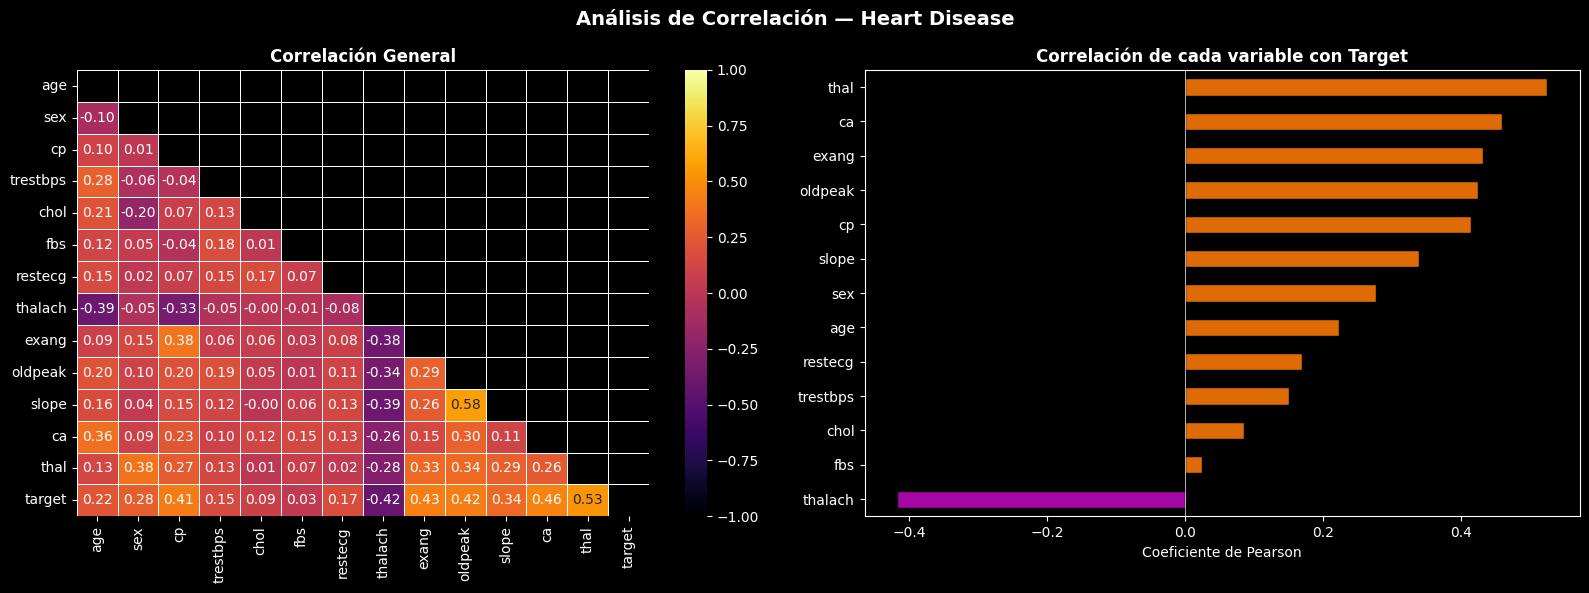

In [595]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlación general

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', 
            cmap='inferno', center=0, ax=axes[0],
            linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Correlación General', fontweight='bold')

# Correlación con el target (barras)

corr_target = df.corr(numeric_only=True)['target'].drop('target').sort_values() 
colores = ["#df6b06" if v > 0 else "#a507a5" for v in corr_target] 
corr_target.plot(kind='barh', ax=axes[1], color=colores, edgecolor='black')
axes[1].axvline(0, color='white', linewidth=0.5)
axes[1].set_title('Correlación de cada variable con Target', fontweight='bold')
axes[1].set_xlabel('Coeficiente de Pearson')

plt.suptitle('Análisis de Correlación — Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [596]:
print("             Antes de limpiar  \n")
print(df.isnull().sum())
print(f"\nShape original: {df.shape}")

# imputación de nulos
# ca y thal son variables categóricas ordinales
# se imputan con la MODA (valor más frecuente)

moda_ca   = df['ca'].mode()[0]
moda_thal = df['thal'].mode()[0]

df['ca']   = df['ca'].fillna(moda_ca)
df['thal'] = df['thal'].fillna(moda_thal)

print(f"\nModa usada para 'ca':   {moda_ca}")
print(f"Moda usada para 'thal': {moda_thal}")

#verificación
print("\n       Despues de limpiar \n")
print(df.isnull().sum())
print(f"\nShape final: {df.shape}")

             Antes de limpiar  

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Shape original: (303, 14)

Moda usada para 'ca':   0.0
Moda usada para 'thal': 3.0

       Despues de limpiar 

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Shape final: (303, 14)


     Feature  Importancia
7    thalach     0.127532
2         cp     0.124639
11        ca     0.117752
12      thal     0.114876
9    oldpeak     0.100619
0        age     0.089359
4       chol     0.081193
3   trestbps     0.070480
8      exang     0.062352
10     slope     0.047018
1        sex     0.033215
6    restecg     0.019810
5        fbs     0.011155


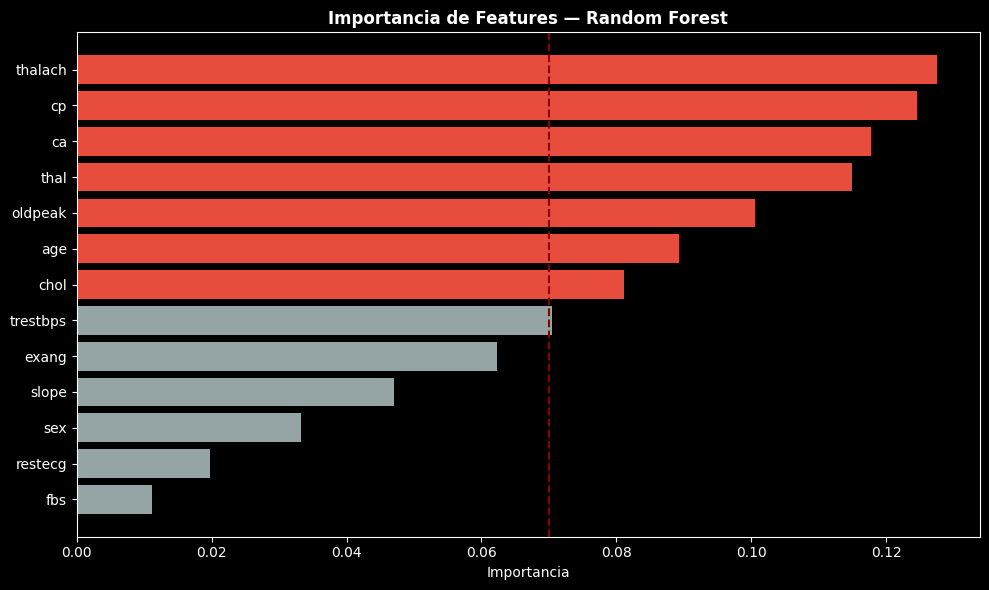

Features seleccionadas: ['age', 'cp', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']
Shape original: (303, 13)
Shape reducido:  (303, 7)


In [597]:
# Separar features y target

X_fs = df.drop('target', axis=1) 
y_fs = df['target'] 

# Entrenar un Random Forest básico para obtener importancias

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_fs, y_fs)

# Se crea un DF con las importancias de mayor a menor

importancias = pd.DataFrame({
    'Feature': X_fs.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False) 

print(importancias)

# Graficar importancias

plt.figure(figsize=(10, 6))
colores = ['#e74c3c' if i < 7 else '#95a5a6' for i in range(len(importancias))]
plt.barh(importancias['Feature'], importancias['Importancia'], color=colores)
plt.xlabel('Importancia')
plt.title('Importancia de Features — Random Forest', fontweight='bold')
plt.axvline(x=0.07, color='darkred', linestyle='--', linewidth=1.5, label='Umbral 7%')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

selector = SelectFromModel(rf, threshold="mean")  # usa el rf ya entrenado
selector.fit(X_fs, y_fs)

X_reducido = selector.transform(X_fs)  # nuevo dataset solo con features importantes

# Ver cuáles quedaron seleccionadas
features_seleccionadas = X_fs.columns[selector.get_support()]
print("Features seleccionadas:", list(features_seleccionadas))
print("Shape original:", X_fs.shape)
print("Shape reducido: ", X_reducido.shape)

In [598]:
# features más importantes

features_seleccionadas = importancias['Feature'].head(7).tolist()
print("Features seleccionadas:", features_seleccionadas)

# Dataset con todas las features (total)

X_total = df.drop('target', axis=1) 

# Dataset solo con features seleccionadas (parcial)

X_parcial = df[features_seleccionadas]
y = df['target']

# Partición 80/20

X_train_total, X_test_total, y_train, y_test = train_test_split(
    X_total, y, test_size=0.2, random_state=42)
X_train_parcial, X_test_parcial, _, _ = train_test_split(
    X_parcial, y, test_size=0.2, random_state=42)

# Evaluar con todas las features (total)

rf_total = RandomForestClassifier(n_estimators=100, random_state=42)
rf_total.fit(X_train_total, y_train)
acc_total = accuracy_score(y_test, rf_total.predict(X_test_total))

# Evaluar con Features seleccionadas (parcial)

rf_parcial = RandomForestClassifier(n_estimators=100, random_state=42)
rf_parcial.fit(X_train_parcial, y_train)
acc_parcial = accuracy_score(y_test, rf_parcial.predict(X_test_parcial))

print(f"\nAccuracy con todas las features (total) =    {acc_total:.4f}")
print(f"Accuracy con features seleccioandas (parcial) =  {acc_parcial:.4f}")

Features seleccionadas: ['thalach', 'cp', 'ca', 'thal', 'oldpeak', 'age', 'chol']

Accuracy con todas las features (total) =    0.8689
Accuracy con features seleccioandas (parcial) =  0.8852


In [599]:
# SVM requiere escalar los datos porque trabaja con distancias

scaler = StandardScaler()

# Features seleccionadas y target

X = df[['thalach', 'cp', 'ca', 'thal', 'oldpeak', 'age', 'chol']]
y = df['target']

# Partición 80/20

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos

X_train_esc = scaler.fit_transform(X_train) # fit_transform en train: aprende la escala y transforma
X_test_esc  = scaler.transform(X_test) # transform en test: solo transforma con la escala aprendida del train

# Hiperparámetros a explorar

param_grid = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C':      [0.1, 1, 10], # C: qué tan estricto es el modelo
    'gamma':  ['scale', 'auto'] # gamma: qué tan lejos "ve" cada punto
}

# GridSearchCV prueba todas las combinaciones posibles

# cv=5: validación cruzada de 5 pliegues

grid_svm = GridSearchCV(SVC(probability=True), param_grid,
                        cv=5, scoring='accuracy', n_jobs=-1)

# Entrenar el modelo con todas las combinaciones

grid_svm.fit(X_train_esc, y_train)

# Mostrar la mejor combinación encontrada

print("Mejores hiperparámetros:", grid_svm.best_params_)
print(f"Mejor accuracy en CV:    {grid_svm.best_score_:.4f}")

# Evaluar en el conjunto de test

y_pred_svm = grid_svm.predict(X_test_esc)
print(f"Accuracy en Test:        {accuracy_score(y_test, y_pred_svm):.4f}")

# Reporte completo 

print("\n                        Reporte completo  \n")
print(classification_report(y_test, y_pred_svm, target_names=['Sano', 'Enfermo']))

Mejores hiperparámetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Mejor accuracy en CV:    0.8221
Accuracy en Test:        0.8852

                        Reporte completo  

              precision    recall  f1-score   support

        Sano       0.87      0.90      0.88        29
     Enfermo       0.90      0.88      0.89        32

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



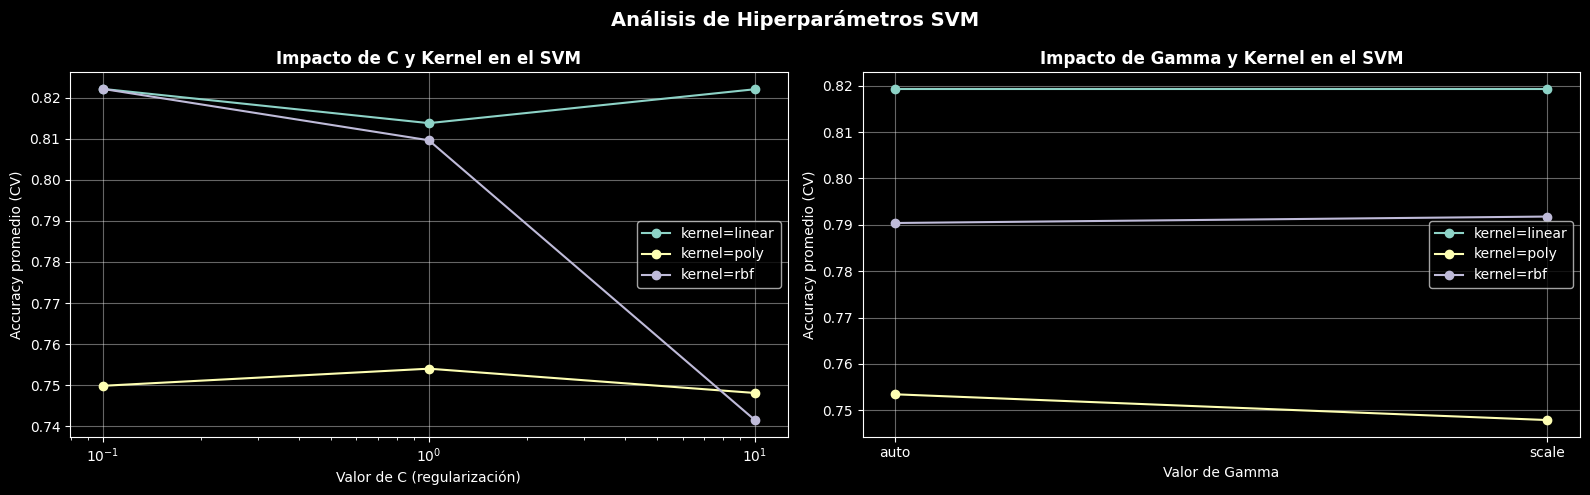


       Efecto promedio de C 

param_C
0.1     0.7980
1.0     0.7925
10.0    0.7706

       Efecto promedio de Gamma 

param_gamma
auto     0.7877
scale    0.7863

       Mejor combinación encontrada 

param_kernel         linear
param_C                 0.1
param_gamma           scale
mean_test_score    0.822109
Name: 0, dtype: object


In [600]:
resultados = pd.DataFrame(grid_svm.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Impacto de C y Kernel 

for kernel in ['linear', 'poly', 'rbf']:
    filtro = resultados[resultados['param_kernel'] == kernel]
    grupo = filtro.groupby('param_C')['mean_test_score'].mean() #Se agrupa por C y se promedia
    line, = axes[0].plot(grupo.index, grupo.values, marker='o', label=f'kernel={kernel}')
    color = line.get_color() 

axes[0].set_xscale('log') 
axes[0].set_xlabel('Valor de C (regularización)')
axes[0].set_ylabel('Accuracy promedio (CV)')
axes[0].set_title('Impacto de C y Kernel en el SVM', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.4) 

#Impacto de Gamma y Kernel

for kernel in ['linear', 'poly', 'rbf']:
    filtro = resultados[resultados['param_kernel'] == kernel]
    grupo = filtro.groupby('param_gamma')['mean_test_score'].mean() #Se agrupa por gamma y se promedia
    line, = axes[1].plot(grupo.index, grupo.values, marker='o', label=f'kernel={kernel}')
    color = line.get_color()
 
axes[1].set_xlabel('Valor de Gamma')
axes[1].set_ylabel('Accuracy promedio (CV)')
axes[1].set_title('Impacto de Gamma y Kernel en el SVM', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Análisis de Hiperparámetros SVM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n       Efecto promedio de C \n")
print(resultados.groupby('param_C')['mean_test_score']
      .mean().round(4).to_string())

print("\n       Efecto promedio de Gamma \n")
print(resultados.groupby('param_gamma')['mean_test_score']
      .mean().round(4).to_string())

print("\n       Mejor combinación encontrada \n")
mejor = resultados.loc[resultados['mean_test_score'].idxmax(),
        ['param_kernel', 'param_C', 'param_gamma', 'mean_test_score']]
print(mejor)

In [601]:
# Hiperparámetros para RF

param_grid_rf = {
    'n_estimators':     [25, 50, 100],
    'max_depth':        [3, 4, 5],      
    'min_samples_split': [5, 10, 15],     # mínimo de muestras para dividir
    'min_samples_leaf':  [3, 5, 10],      # mínimo de muestras en cada hoja
    'max_features':     ['sqrt', 'log2']  # limitar features por árbol
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

# Mejores hiperparámetros

print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Mejor accuracy en CV:    {grid_rf.best_score_:.4f}")

# Evaluar en train y test

y_pred_rf_train = grid_rf.predict(X_train)
y_pred_rf_test  = grid_rf.predict(X_test)

print(f"\nAccuracy en Train: {accuracy_score(y_train, y_pred_rf_train):.4f}")
print(f"Accuracy en Test:  {accuracy_score(y_test, y_pred_rf_test):.4f}")

print("\n                       Reporte completo \n")
print(classification_report(y_test, y_pred_rf_test,target_names=['Sano', 'Enfermo']))

mejor_rf = grid_rf.best_estimator_
cv_rf = cross_val_score(mejor_rf, X_train, y_train, cv=10, scoring='accuracy') # Validación cruzada k=10
print(f"\nCV k=10 — Media: {cv_rf.mean():.4f} | Std: {cv_rf.std():.4f}")

Mejores hiperparámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 25}
Mejor accuracy en CV:    0.8140

Accuracy en Train: 0.8760
Accuracy en Test:  0.8689

                       Reporte completo 

              precision    recall  f1-score   support

        Sano       0.82      0.93      0.87        29
     Enfermo       0.93      0.81      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


CV k=10 — Media: 0.7937 | Std: 0.0632


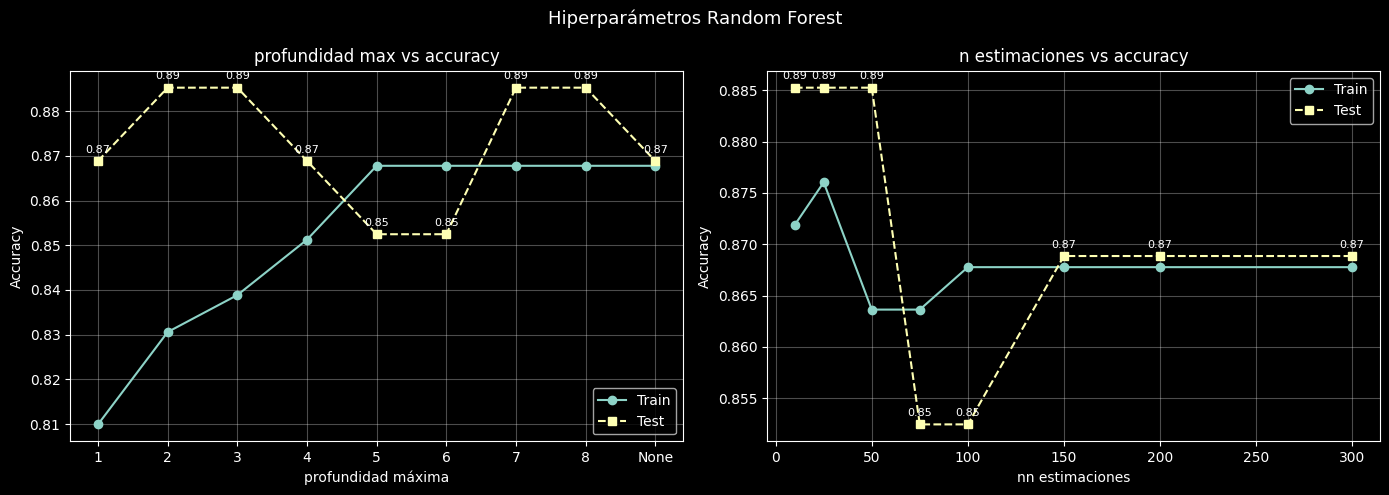

mejor profundidad máxima = 2  ---> acc test = 0.8852
mejor n estimaciones = 10  ---> acc test = 0.8852


In [602]:
# efecto de max_depth

profundidades = [1, 2, 3, 4, 5, 6, 7, 8, None]
acc_train_profun = []
acc_test_profun  = []

for d in profundidades:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=d,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=42
    )
    rf.fit(X_train, y_train)
    acc_train_profun.append(accuracy_score(y_train, rf.predict(X_train)))
    acc_test_profun.append(accuracy_score(y_test,  rf.predict(X_test)))

# efecto de n_estimators

arboles = [10, 25, 50, 75, 100, 150, 200, 300]
acc_train_est = []
acc_test_est  = []

for n in arboles:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=5,           
        min_samples_leaf=5,   
        min_samples_split=10,  
        max_features='sqrt',   
        random_state=42)
    rf.fit(X_train, y_train)
    acc_train_est.append(accuracy_score(y_train, rf.predict(X_train)))
    acc_test_est.append(accuracy_score(y_test,  rf.predict(X_test)))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#max_depth
etiquetas_profun = [str(d) if d is not None else 'None' for d in profundidades]

axes[0].plot(etiquetas_profun, acc_train_profun, marker='o', label='Train')
axes[0].plot(etiquetas_profun, acc_test_profun,  marker='s', label='Test', linestyle='--')

# poner los valores encima de los puntos de test
for i, te in enumerate(acc_test_profun):
    axes[0].annotate(f'{te:.2f}', xy=(i, te), xytext=(0, 6),
                     textcoords='offset points', ha='center', fontsize=8)

axes[0].set_xlabel('profundidad máxima')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('profundidad max vs accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#n_estimators
axes[1].plot(arboles, acc_train_est, marker='o', label='Train')
axes[1].plot(arboles, acc_test_est,  marker='s', label='Test', linestyle='--')

for x, te in zip(arboles, acc_test_est):
    axes[1].annotate(f'{te:.2f}', xy=(x, te), xytext=(0, 6),
                     textcoords='offset points', ha='center', fontsize=8)

axes[1].set_xlabel('nn estimaciones')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('n estimaciones vs accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Hiperparámetros Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

# resultados
mejor_profun = profundidades[np.argmax(acc_test_profun)]
mejor_est   = arboles[np.argmax(acc_test_est)]

print(f"mejor profundidad máxima = {mejor_profun}  ---> acc test = {max(acc_test_profun):.4f}")
print(f"mejor n estimaciones = {mejor_est}  ---> acc test = {max(acc_test_est):.4f}")

In [603]:
# Hiperparámetros a explorar
param_grid_xgb = {
    'n_estimators':  [50, 100],
    'max_depth':     [ 2, 3, 4],     
    'learning_rate': [0.01, 0.05],    
    'gamma':         [0.1, 0.5, 1],   #más penalización
    'reg_lambda':    [5, 10],         #más regularización L2
    'reg_alpha':     [0.1, 0.5],      #más regularización L1
    'subsample':     [0.7, 0.8],      #usar solo parte de los datos
    'colsample_bytree': [0.7, 0.8],   #usar solo parte de las features
    "scale_pos_weight": [1, 1.18]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss' #para evitar warnings de evaluación en clasificación binaria
    ),
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# XGBoost tampoco requiere escalar

grid_xgb.fit(X_train, y_train)

# Mejores hiperparámetros
print("Mejores hiperparámetros = ", grid_xgb.best_params_)
print(f"Mejor accuracy en CV =    {grid_xgb.best_score_:.4f}")

y_pred_xgb_train = grid_xgb.predict(X_train)
y_pred_xgb_test  = grid_xgb.predict(X_test)

print(f"\nAccuracy en Train = {accuracy_score(y_train, y_pred_xgb_train):.4f}")
print(f"Accuracy en Test =  {accuracy_score(y_test, y_pred_xgb_test):.4f}")

print("\n                      Reporte completo \n")
print(classification_report(y_test, y_pred_xgb_test,target_names=['Sano', 'Enfermo']))


mejor_xgb = grid_xgb.best_estimator_
cv_xgb = cross_val_score(mejor_xgb, X_train, y_train, cv=10, scoring='accuracy') # Validación cruzada k=10
print(f"\nCV k=10 — Media: {cv_xgb.mean():.4f} | Std: {cv_xgb.std():.4f}")

Mejores hiperparámetros =  {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 10, 'scale_pos_weight': 1.18, 'subsample': 0.7}
Mejor accuracy en CV =    0.8264

Accuracy en Train = 0.8264
Accuracy en Test =  0.8361

                      Reporte completo 

              precision    recall  f1-score   support

        Sano       0.77      0.93      0.84        29
     Enfermo       0.92      0.75      0.83        32

    accuracy                           0.84        61
   macro avg       0.85      0.84      0.84        61
weighted avg       0.85      0.84      0.84        61


CV k=10 — Media: 0.8100 | Std: 0.0459


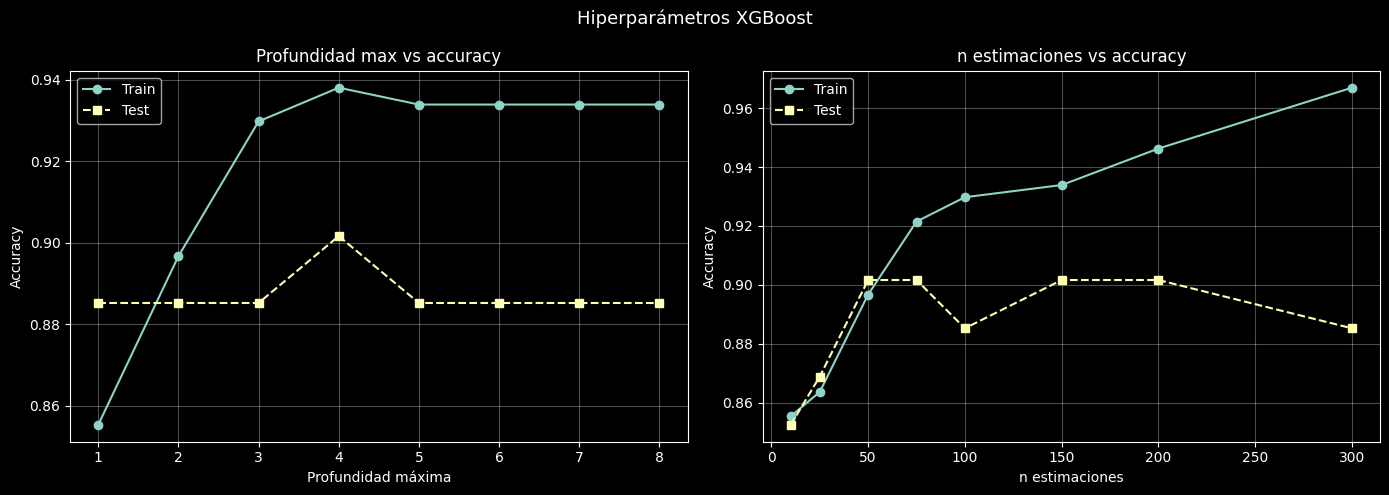

mejor profundidad max = 4  ---> acc test = 0.9016
mejor n estimaciones = 50  ---> acc test= 0.9016


In [604]:
# efecto de max_depth

profundidades = [1, 2, 3, 4, 5, 6, 7, 8]  # XGBoost no acepta None
acc_train_profun = []
acc_test_profun  = []

for d in profundidades:
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=d,
        learning_rate=0.1,     
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,    
        random_state=42,
        eval_metric='logloss'
    )
    xgb.fit(X_train, y_train)
    acc_train_profun.append(accuracy_score(y_train, xgb.predict(X_train)))
    acc_test_profun.append(accuracy_score(y_test,   xgb.predict(X_test)))

# efecto de n_estimators
arboles = [10, 25, 50, 75, 100, 150, 200, 300]
acc_train_est = []
acc_test_est  = []

for n in arboles:
    xgb = XGBClassifier(
        n_estimators=n,
        max_depth=3,           
        learning_rate=0.1,    
        subsample=0.8,         
        colsample_bytree=0.8,  
        min_child_weight=3,    
        random_state=42,
        eval_metric='logloss'
    )
    xgb.fit(X_train, y_train)
    acc_train_est.append(accuracy_score(y_train, xgb.predict(X_train)))
    acc_test_est.append(accuracy_score(y_test,   xgb.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#max_depth

etiquetas_depth = []
for d in profundidades:
    etiquetas_depth.append(str(d))

axes[0].plot(etiquetas_depth, acc_train_profun, marker='o', label='Train')
axes[0].plot(etiquetas_depth, acc_test_profun,  marker='s', label='Test', linestyle='--')
axes[0].set_xlabel('Profundidad máxima')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Profundidad max vs accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#n_estimators

axes[1].plot(arboles, acc_train_est, marker='o', label='Train')
axes[1].plot(arboles, acc_test_est,  marker='s', label='Test', linestyle='--')
axes[1].set_xlabel('n estimaciones')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('n estimaciones vs accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Hiperparámetros XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

mejor_profun = profundidades[np.argmax(acc_test_profun)]
mejor_est   = arboles[np.argmax(acc_test_est)]

print(f"mejor profundidad max = {mejor_profun}  ---> acc test = {max(acc_test_profun):.4f}")
print(f"mejor n estimaciones = {mejor_est}  ---> acc test= {max(acc_test_est):.4f}")

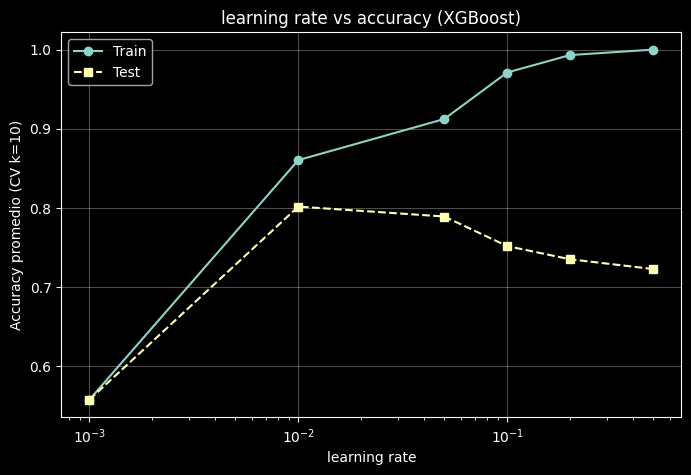

mejor learning_rate: 0.01  ---> CV accuracy: 0.8017


In [605]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
cv_train_lr = []
cv_test_lr  = []

for lr in learning_rates:
    xgb = XGBClassifier(
        learning_rate=lr,
        n_estimators=100,
        max_depth=3,
        random_state=42,
        eval_metric='logloss'
    )
    resultado = cross_validate(xgb, X_train, y_train, cv=kf,scoring='accuracy',return_train_score=True)
    cv_train_lr.append(resultado['train_score'].mean())
    cv_test_lr.append(resultado['test_score'].mean())

plt.figure(figsize=(8, 5))
plt.plot(learning_rates, cv_train_lr, marker='o', label='Train')
plt.plot(learning_rates, cv_test_lr,  marker='s', label='Test', linestyle='--')
plt.xscale('log')  # escala logaritmica porque los valores van de 0.001 a 0.5
plt.xlabel('learning rate')
plt.ylabel('Accuracy promedio (CV k=10)')
plt.title('learning rate vs accuracy (XGBoost)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

mejor_lr = learning_rates[cv_test_lr.index(max(cv_test_lr))]
print(f"mejor learning_rate: {mejor_lr}  ---> CV accuracy: {max(cv_test_lr):.4f}")

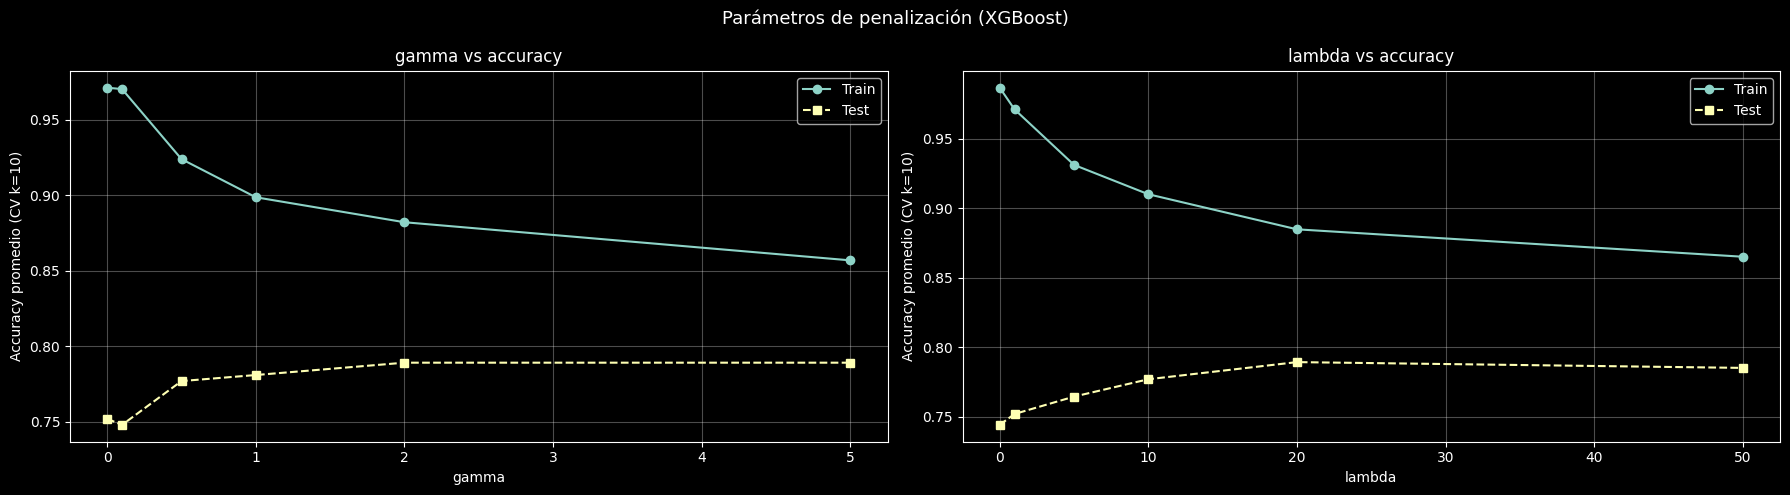

mejor gamma = 2   ---> CV accuracy: 0.7890
mejor lambda = 20   ---> CV accuracy: 0.7892


In [606]:
# gamma
gammas = [0, 0.1, 0.5, 1, 2, 5]
cv_train_gamma = []
cv_test_gamma  = []

for g in gammas:
    xgb = XGBClassifier(
        gamma=g,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )
    resultado = cross_validate(xgb, X_train, y_train, cv=kf,
                               scoring='accuracy',
                               return_train_score=True)
    cv_train_gamma.append(resultado['train_score'].mean())
    cv_test_gamma.append(resultado['test_score'].mean())

# lambda
lambdas = [0, 1, 5, 10, 20, 50]
cv_train_lambda = []
cv_test_lambda  = []

for l in lambdas:
    xgb = XGBClassifier(
        reg_lambda=l,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )
    resultado = cross_validate(xgb, X_train, y_train, cv=kf,
                               scoring='accuracy',
                               return_train_score=True)
    cv_train_lambda.append(resultado['train_score'].mean())
    cv_test_lambda.append(resultado['test_score'].mean())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(gammas,  cv_train_gamma,  marker='o', label='Train')
axes[0].plot(gammas,  cv_test_gamma,   marker='s', label='Test', linestyle='--')
axes[0].set_xlabel('gamma')
axes[0].set_ylabel('Accuracy promedio (CV k=10)')
axes[0].set_title('gamma vs accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lambdas, cv_train_lambda, marker='o', label='Train')
axes[1].plot(lambdas, cv_test_lambda,  marker='s', label='Test', linestyle='--')
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('Accuracy promedio (CV k=10)')
axes[1].set_title('lambda vs accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Parámetros de penalización (XGBoost)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"mejor gamma = {gammas[cv_test_gamma.index(max(cv_test_gamma))]}   ---> CV accuracy: {max(cv_test_gamma):.4f}")
print(f"mejor lambda = {lambdas[cv_test_lambda.index(max(cv_test_lambda))]}   ---> CV accuracy: {max(cv_test_lambda):.4f}")

negativos = 135 | positivos = 107 | ratio = 1.26


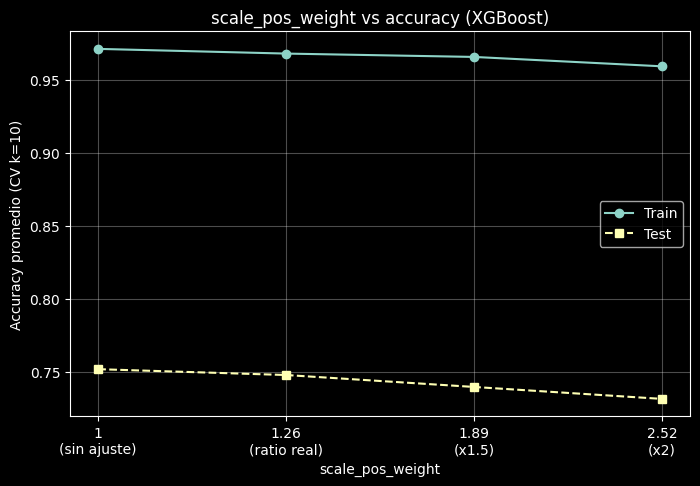

mejor scale_pos_weight = 1.00  ---> CV accuracy = 0.7518


In [607]:
#ratio real del dataset

negativos = (y_train == 0).sum()
positivos  = (y_train == 1).sum()
ratio = negativos / positivos
print(f"negativos = {negativos} | positivos = {positivos} | ratio = {ratio:.2f}")

pesos = [1, ratio, ratio * 1.5, ratio * 2]
etiquetas_pesos = ['1\n(sin ajuste)', f'{ratio:.2f}\n(ratio real)',
                   f'{ratio*1.5:.2f}\n(x1.5)', f'{ratio*2:.2f}\n(x2)']
cv_train_epp = []
cv_test_epp  = []

for w in pesos:
    xgb = XGBClassifier(
        scale_pos_weight=w,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )
    resultado = cross_validate(xgb, X_train, y_train, cv=kf,
                               scoring='accuracy',
                               return_train_score=True)
    cv_train_epp.append(resultado['train_score'].mean())
    cv_test_epp.append(resultado['test_score'].mean())

plt.figure(figsize=(8, 5))
plt.plot(etiquetas_pesos, cv_train_epp, marker='o', label='Train')
plt.plot(etiquetas_pesos, cv_test_epp,  marker='s', label='Test', linestyle='--')
plt.xlabel('scale_pos_weight')
plt.ylabel('Accuracy promedio (CV k=10)')
plt.title('scale_pos_weight vs accuracy (XGBoost)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

mejor_idx = cv_test_epp.index(max(cv_test_epp))
print(f"mejor scale_pos_weight = {pesos[mejor_idx]:.2f}  ---> CV accuracy = {max(cv_test_epp):.4f}")

********META-MODELO********

In [608]:
modelos_base = [
    ('logistica',  LogisticRegression(max_iter=1000, random_state=42)),
    ('knn',        KNeighborsClassifier(n_neighbors=7)),
    ('arbol',      DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svm',        SVC(kernel='rbf', probability=True, random_state=42,C=grid_svm.best_params_['C'], gamma=grid_svm.best_params_['gamma']),),
    ('naive_bayes', GaussianNB()),
]

meta_modelo = LogisticRegression(max_iter=1000, random_state=42)

stacking = StackingClassifier(
    estimators=modelos_base,
    final_estimator=meta_modelo,
    cv=5,                   
    passthrough=False        # solo usa predicciones, no features originales
)

stacking.fit(X_train_esc, y_train)

y_pred_stack_train = stacking.predict(X_train_esc)
y_pred_stack_test  = stacking.predict(X_test_esc)

print(f"Accuracy en Train: {accuracy_score(y_train, y_pred_stack_train):.4f}")
print(f"Accuracy en Test:  {accuracy_score(y_test, y_pred_stack_test):.4f}")
print(f"Diferencia:        {accuracy_score(y_train, y_pred_stack_train) - accuracy_score(y_test, y_pred_stack_test):.4f}")

print("\n                               Reporte \n")
print(classification_report(y_test, y_pred_stack_test,
      target_names=['Sano', 'Enfermo']))

cv_stack = cross_val_score(stacking, X_train_esc, y_train,cv=10, scoring='accuracy') 
print(f"\nCV k=10 — Media = {cv_stack.mean():.4f} | Std = {cv_stack.std():.4f}") 

Accuracy en Train: 0.8636
Accuracy en Test:  0.8689
Diferencia:        -0.0052

                               Reporte 

              precision    recall  f1-score   support

        Sano       0.86      0.86      0.86        29
     Enfermo       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


CV k=10 — Media = 0.8103 | Std = 0.0606


In [609]:
# calculamos train y test accuracy para cada modelo

modelos_gen = {
    'SVM':           (grid_svm.best_estimator_, X_train_esc, X_test_esc),
    'Random Forest': (grid_rf.best_estimator_,  X_train,     X_test),
    'XGBoost':       (grid_xgb.best_estimator_, X_train,     X_test),
    'Stacking':      (stacking,                 X_train_esc, X_test_esc)
}

filas_gen = []

for nombre, (modelo, X_tr, X_te) in modelos_gen.items():
    acc_train = accuracy_score(y_train, modelo.predict(X_tr))
    acc_test  = accuracy_score(y_test,  modelo.predict(X_te))
    brecha    = acc_train - acc_test

    if brecha > 0.10:
        estado = 'Overfitting'
    elif brecha < -0.02:
        estado = 'Underfitting'
    else:
        estado = 'Balanceado'

    filas_gen.append({
        'Modelo':      nombre,
        'Train Acc':   round(acc_train, 4),
        'Test Acc':    round(acc_test, 4),
        'Brecha':      round(brecha, 4),
        'Estado':      estado
    })

df_gen = pd.DataFrame(filas_gen).set_index('Modelo')
print(df_gen.to_string())

               Train Acc  Test Acc  Brecha        Estado
Modelo                                                  
SVM               0.8430    0.8852 -0.0423  Underfitting
Random Forest     0.8760    0.8689  0.0072    Balanceado
XGBoost           0.8264    0.8361 -0.0096    Balanceado
Stacking          0.8636    0.8689 -0.0052    Balanceado


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27016\439440093.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(nombres, rotation=10)


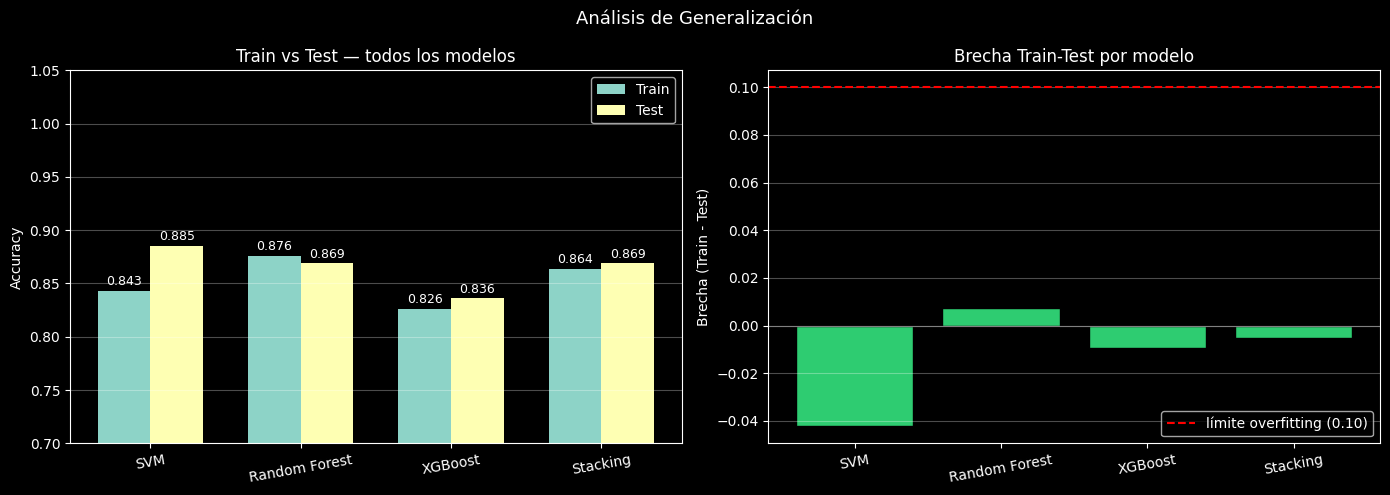

In [610]:
#Gráfica test vs train

nombres = df_gen.index.tolist() 
x       = np.arange(len(nombres))
ancho   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#barras train vs test

bars1 = axes[0].bar(x - ancho/2, df_gen['Train Acc'], ancho, label='Train')
bars2 = axes[0].bar(x + ancho/2, df_gen['Test Acc'],  ancho, label='Test', linestyle='--')

for bar in bars1:
    axes[0].annotate(f'{bar.get_height():.3f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=9)
for bar in bars2:
    axes[0].annotate(f'{bar.get_height():.3f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres, rotation=10)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test — todos los modelos')
axes[0].set_ylim(0.7, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

#brecha de cada modelo

colores_brecha = ['#e74c3c' if b > 0.10 else '#2ecc71'
                  for b in df_gen['Brecha']]
axes[1].bar(nombres, df_gen['Brecha'], color=colores_brecha, edgecolor='black')
axes[1].axhline(y=0.10, color='red', linestyle='--',
                linewidth=1.5, label='límite overfitting (0.10)')
axes[1].axhline(y=0.00, color='gray', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Brecha (Train - Test)')
axes[1].set_title('Brecha Train-Test por modelo')
axes[1].set_xticklabels(nombres, rotation=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Análisis de Generalización', fontsize=13)
plt.tight_layout()
plt.show()

In [611]:
y_pred_svm = grid_svm.predict(X_test_esc)
y_pred_rf  = grid_rf.predict(X_test)
y_pred_xgb = grid_xgb.predict(X_test)
y_pred_stk = stacking.predict(X_test_esc)

resultados_metricas = []

for nombre, y_pred in [('SVM', y_pred_svm),
                        ('Random Forest', y_pred_rf),
                        ('XGBoost', y_pred_xgb),
                        ('Stacking', y_pred_stk)]:
    resultados_metricas.append({
        'Modelo':          nombre,
        'Accuracy':        round(accuracy_score(y_test, y_pred), 4),
        'Precisión Sano':  round(precision_score(y_test, y_pred, pos_label=0), 4),
        'Precisión Enf':   round(precision_score(y_test, y_pred, pos_label=1), 4),
        'Recall Sano':     round(recall_score(y_test, y_pred, pos_label=0), 4),
        'Recall Enfermo':  round(recall_score(y_test, y_pred, pos_label=1), 4),
        'F1 Sano':         round(f1_score(y_test, y_pred, pos_label=0), 4),
        'F1 Enfermo':      round(f1_score(y_test, y_pred, pos_label=1), 4),
    })

df_metricas = pd.DataFrame(resultados_metricas).set_index('Modelo')
print(df_metricas.to_string())

               Accuracy  Precisión Sano  Precisión Enf  Recall Sano  Recall Enfermo  F1 Sano  F1 Enfermo
Modelo                                                                                                  
SVM              0.8852          0.8667         0.9032       0.8966          0.8750   0.8814      0.8889
Random Forest    0.8689          0.8182         0.9286       0.9310          0.8125   0.8710      0.8667
XGBoost          0.8361          0.7714         0.9231       0.9310          0.7500   0.8438      0.8276
Stacking         0.8689          0.8621         0.8750       0.8621          0.8750   0.8621      0.8750


## Justificación de métricas en el contexto médico

En detección de enfermedades cardíacas cada métrica tiene
un significado clínico concreto:

- *Accuracy*: porcentaje total de pacientes bien clasificados.
  Sirve como referencia general pero no es suficiente sola.

- *Precisión*: de los que el modelo dijo "enfermo", cuántos
  realmente lo estaban. Una precisión baja genera alarmas falsas —
  pacientes sanos sometidos a exámenes innecesarios y costosos.

- *Recall (Sensibilidad)*: de todos los pacientes realmente
  enfermos, cuántos detectó el modelo. Es la métrica más crítica
  en este problema.

- *F1-Score*: balance entre precisión y recall.

### ¿Por qué es más costoso un Falso Negativo?

| Error | Situación | Consecuencia |
|---|---|---|
| Falso Positivo | Sano clasificado como Enfermo | Exámenes extra, estrés, costo económico — recuperable |
| Falso Negativo | Enfermo clasificado como Sano | Sin tratamiento, riesgo de muerte — irreversible |

*Conclusión:* en este problema se prioriza maximizar el *Recall*
por encima de la precisión. Un modelo con Recall alto garantiza
que la mayoría de pacientes enfermos sean detectados, aunque
implique algunas alarmas falsas.

In [612]:
SKF = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metricas = ['accuracy', 'precision', 'recall', 'f1']

X_cv = df[features_seleccionadas]
y_cv = df['target']

# SVM necesita escalar en cada pliegue
pipe_svm = make_pipeline(StandardScaler(), grid_svm.best_estimator_)

modelos_cv = {
    'SVM':           pipe_svm,
    'Random Forest': grid_rf.best_estimator_,
    'XGBoost':       grid_xgb.best_estimator_,
    'Stacking':      stacking
}

filas = []

for nombre, modelo in modelos_cv.items():
    scores = cross_validate(modelo, X_cv, y_cv,
                            cv=SKF, 
                            scoring=metricas,
                            return_train_score=False)
    filas.append({
        'Modelo':       nombre,
        'Accuracy (1)':   round(scores['test_accuracy'].mean(), 4),
        'Accuracy (2)':   round(scores['test_accuracy'].std(), 4),
        'Precisión (1)':  round(scores['test_precision'].mean(), 4),
        'Precisión (2)':  round(scores['test_precision'].std(), 4),
        'Recall (1)':     round(scores['test_recall'].mean(), 4),
        'Recall (2)':     round(scores['test_recall'].std(), 4),
        'F1 (1)':         round(scores['test_f1'].mean(), 4),
        'F1 (2)':         round(scores['test_f1'].std(), 4),
    })

df_cv = pd.DataFrame(filas).set_index('Modelo')
print("\n 1 = promedio | 2 = desviación estándar \n")
print(df_cv.to_string())


 1 = promedio | 2 = desviación estándar 

               Accuracy (1)  Accuracy (2)  Precisión (1)  Precisión (2)  Recall (1)  Recall (2)  F1 (1)  F1 (2)
Modelo                                                                                                         
SVM                  0.8274        0.0846         0.8506         0.1104      0.7692      0.1064  0.8038  0.0919
Random Forest        0.8212        0.0610         0.8531         0.1002      0.7473      0.0775  0.7933  0.0707
XGBoost              0.8378        0.0492         0.8659         0.0866      0.7769      0.0674  0.8152  0.0525
Stacking             0.8276        0.0801         0.8472         0.0998      0.7692      0.1064  0.8031  0.0904


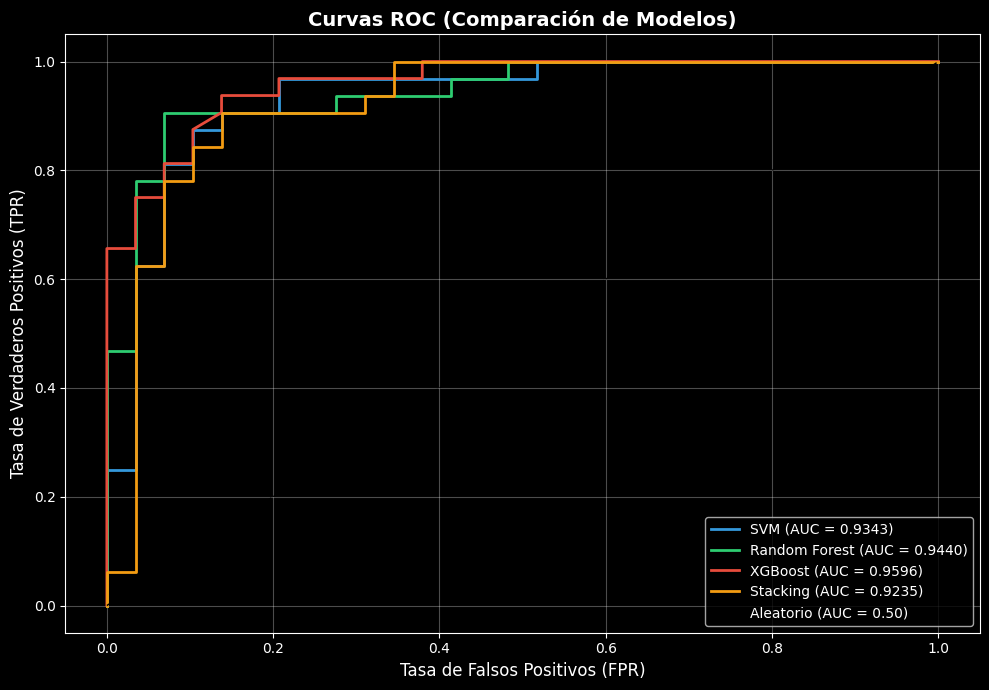

In [613]:
fig, ax = plt.subplots(figsize=(10, 7))

#Probabilidades de cada modelo

modelos_roc = {
    'SVM':           grid_svm.predict_proba(X_test_esc)[:, 1],
    'Random Forest': grid_rf.predict_proba(X_test)[:, 1],
    'XGBoost':       grid_xgb.predict_proba(X_test)[:, 1],
    'Stacking':      stacking.predict_proba(X_test_esc)[:, 1]
}

colores_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (nombre, probs), color in zip(modelos_roc.items(), colores_roc): #in zip es para iterar ambos al mismo tiempo
    fpr, tpr, _ = roc_curve(y_test, probs) #_ es para ignorar el tercer valor que devuelve roc_curve (thresholds)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{nombre} (AUC = {auc:.4f})')

# Línea base (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.50)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC (Comparación de Modelos)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

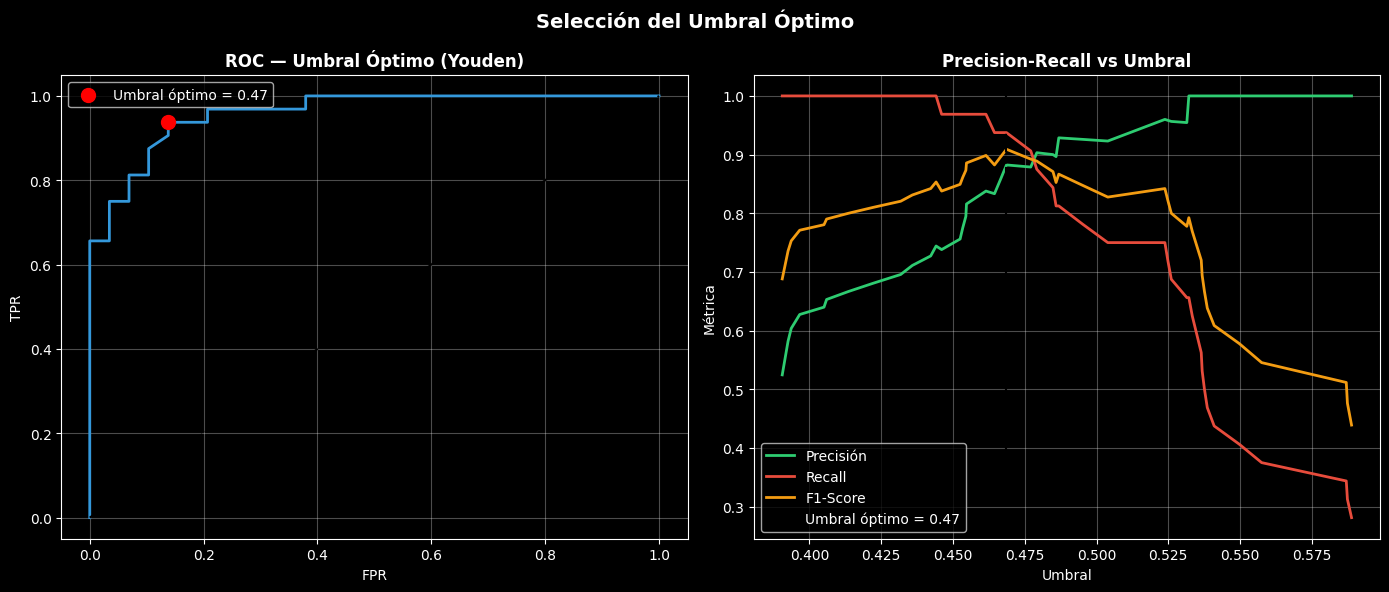

Umbral óptimo por Youden (ROC) =          0.4686
Umbral óptimo por F1 (Precision-Recall) = 0.4686

             Resultados con umbral óptimo (0.47) =  

              precision    recall  f1-score   support

        Sano       0.93      0.86      0.89        29
     Enfermo       0.88      0.94      0.91        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [614]:
#Usar el mejor modelo (el que tenga mayor AUC)
#Stacking o XGBoost según resultados

probs_mejor = grid_xgb.predict_proba(X_test)[:, 1]

#Curva ROC con umbral óptimo

fpr, tpr, umbrales_roc = roc_curve(y_test, probs_mejor)

#Índice de Youden: maximiza TPR - FPR

indice_youden = tpr - fpr
umbral_optimo_roc = umbrales_roc[indice_youden.argmax()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Gráfica

axes[0].plot(fpr, tpr, color='#3498db', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].scatter(fpr[indice_youden.argmax()],
                tpr[indice_youden.argmax()],
                color='red', s=100, zorder=5, #s es el tamaño del punto, zorder es para que quede por encima de la línea
                label=f'Umbral óptimo = {umbral_optimo_roc:.2f}')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — Umbral Óptimo (Youden)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

#Curva Precision-Recall 

precision, recall, umbrales_pr = precision_recall_curve(y_test, probs_mejor)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
umbral_optimo_pr = umbrales_pr[f1_scores[:-1].argmax()]

axes[1].plot(umbrales_pr, precision[:-1], color='#2ecc71',
             linewidth=2, label='Precisión')
axes[1].plot(umbrales_pr, recall[:-1], color='#e74c3c',
             linewidth=2, label='Recall')
axes[1].plot(umbrales_pr, f1_scores[:-1], color='#f39c12',
             linewidth=2, label='F1-Score')
axes[1].axvline(umbral_optimo_pr, color='black', linestyle='--',
                label=f'Umbral óptimo = {umbral_optimo_pr:.2f}')
axes[1].set_xlabel('Umbral')
axes[1].set_ylabel('Métrica')
axes[1].set_title('Precision-Recall vs Umbral', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Selección del Umbral Óptimo', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Umbral óptimo por Youden (ROC) =          {umbral_optimo_roc:.4f}")
print(f"Umbral óptimo por F1 (Precision-Recall) = {umbral_optimo_pr:.4f}")

y_pred_umbral = (probs_mejor >= umbral_optimo_roc).astype(int)
print(f"\n             Resultados con umbral óptimo ({umbral_optimo_roc:.2f}) =  \n")
print(classification_report(y_test, y_pred_umbral,target_names=['Sano', 'Enfermo']))

In [615]:
#Crear explainer
# se usa el mejor modelo de XGBoost encontrado por GridSearchCV

modelo_ganador = grid_xgb.best_estimator_

explainer = shap.TreeExplainer(modelo_ganador)

# calcular los valores SHAP sobre el conjunto de test

X_test_df = pd.DataFrame(X_test, columns=features_seleccionadas)
shap_values = explainer.shap_values(X_test_df)

print(f"Shape de shap_values = {shap_values.shape}")
print(f"Features = {features_seleccionadas}")

Shape de shap_values = (61, 7)
Features = ['thalach', 'cp', 'ca', 'thal', 'oldpeak', 'age', 'chol']


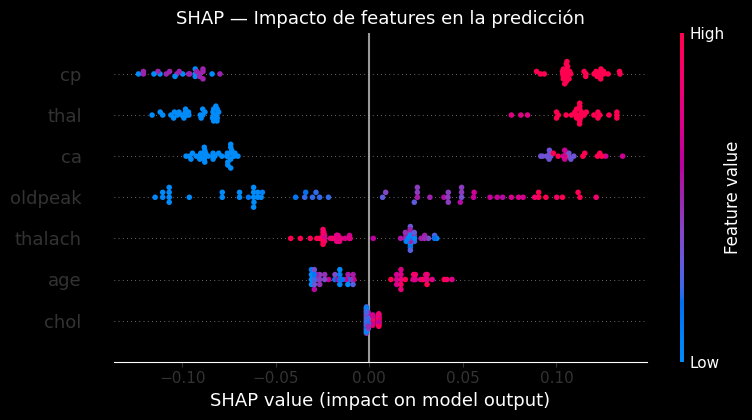

In [616]:
plt.figure()
shap.summary_plot(shap_values, X_test_df,
                  feature_names=features_seleccionadas,
                  show=False)
plt.title('SHAP — Impacto de features en la predicción', fontsize=13)
plt.tight_layout()
plt.show()

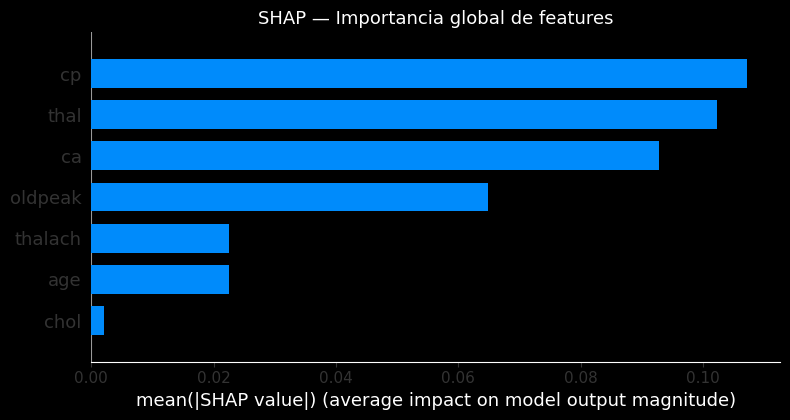

In [617]:
plt.figure()
shap.summary_plot(shap_values, X_test_df,
                  feature_names=features_seleccionadas,
                  plot_type='bar',
                  show=False)
plt.title('SHAP — Importancia global de features', fontsize=13)
plt.tight_layout()
plt.show()

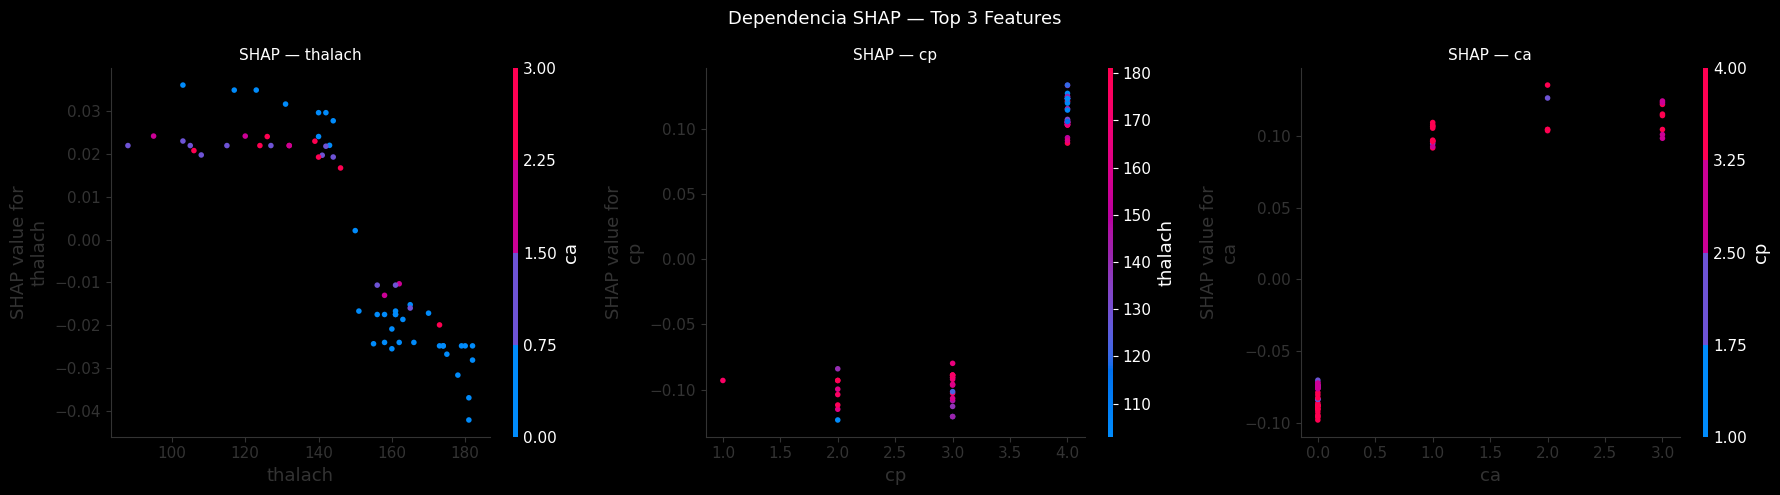

In [618]:
top3_features = features_seleccionadas[:3]  # ajusta según lo que salga en el summary plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, features in enumerate(top3_features):
    shap.dependence_plot(features, shap_values, X_test_df,
                         ax=axes[i], show=False)
    axes[i].set_title(f'SHAP — {features}', fontsize=11)

plt.suptitle('Dependencia SHAP — Top 3 Features', fontsize=13)
plt.tight_layout()
plt.show()

Paciente 0 = 

thalach    173.0
cp           3.0
ca           3.0
thal         3.0
oldpeak      0.0
age         53.0
chol       246.0
Name: 179, dtype: float64

Predicción real =  Sano
Predicción modelo = Sano


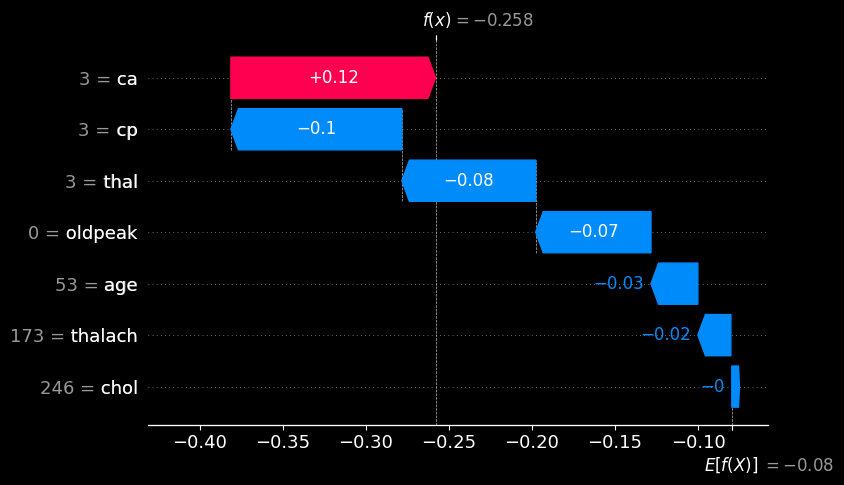

In [619]:
idx_paciente = 0  # puedes cambiar este índice para analizar otro paciente del conjunto de test

print(f"Paciente {idx_paciente} = \n")
print(X_test_df.iloc[idx_paciente])
print(f"\nPredicción real =  {'Enfermo' if y_test.iloc[idx_paciente] == 1 else 'Sano'}")
print(f"Predicción modelo = {'Enfermo' if modelo_ganador.predict(X_test_df.iloc[[idx_paciente]])[0] == 1 else 'Sano'}")

shap.waterfall_plot(
    shap.Explanation( #crea una explicación para el paciente específico
        values=shap_values[idx_paciente],
        base_values=explainer.expected_value, #valor de referencia para la predicción
        data=X_test_df.iloc[idx_paciente],
        feature_names=features_seleccionadas
    )
)